In [1]:
%load_ext autoreload
%autoreload 2 --full

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from datat_processing_fct import load_experiment_data, filter_training, filter_training_constant, filter_training_var, filter_evaluation, filter_evaluation_constant, filter_evaluation_var, apply_normalization, average_normalized_heading_by_fours
from exponential_fct import _fit_exp, create_split_plot_xy

from typing import Dict, List, Tuple

In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'lines.linewidth': 0.75,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'mathtext.fontset': 'cm',
})

group_colors = {
    "Const": '#ffb000',
    "Random": '#785ef0',
    "Error": '#fe6100',
    "Pref": '#dc267f',
    "Var": '#648fff',
}

In [3]:
data_random = load_experiment_data(
    root_dir="",
    training_method=["random_learning"],
    json_type="regular",
    sections=["target","params"]
)

data_constant = load_experiment_data(
    root_dir="",
    training_method=["constant_learning"],
    json_type="regular",
    sections=["target","params"]
)

data_perf = load_experiment_data(
    root_dir="",
    training_method=["cma_learning"],
    json_type="regular",
    sections=["target","params"]
)

data_pref = load_experiment_data(
    root_dir="",
    training_method=["preference_learning"],
    json_type="regular",
    sections=["target","params"]
)

data_var = load_experiment_data(
    root_dir="",
    training_method=["variational_learning"],
    json_type="regular",
    sections=["target","params"]
)

In [4]:
data_perf_train = filter_training(data_perf)
data_pref_train = filter_training(data_pref)
data_random_train = filter_training(data_random)
data_constant_train = filter_training_constant(data_constant)
data_var_train = filter_training_var(data_var)
# Expand var repetition data to simulate 3-angle trials
for key in data_var_train.keys():
    newdata = []
    for i in range(len(data_var_train[key])):
        if i in [0,1,2,18,19,20,36,37,38,54,55,56]:
            for _ in range(6):
                newdata.append(data_var_train[key][i])
        else:
            newdata.append(data_var_train[key][i])
    data_var_train[key] = newdata

In [5]:
data_random_eval = filter_evaluation(data_random)
data_random_eval_norm = apply_normalization(data_random_eval)
data_random_eval_avg = average_normalized_heading_by_fours(data_random_eval_norm)

data_perf_eval = filter_evaluation(data_perf)
data_perf_eval_norm = apply_normalization(data_perf_eval)
data_perf_eval_avg = average_normalized_heading_by_fours(data_perf_eval_norm)

data_pref_eval = filter_evaluation(data_pref)
data_pref_eval_norm = apply_normalization(data_pref_eval)
data_pref_eval_avg = average_normalized_heading_by_fours(data_pref_eval_norm)

data_constant_eval = filter_evaluation_constant(data_constant)
data_constant_eval_norm = apply_normalization(data_constant_eval)
data_constant_eval_avg = average_normalized_heading_by_fours(data_constant_eval_norm)

data_var_eval = filter_evaluation_var(data_var)
data_var_eval_norm = apply_normalization(data_var_eval)
data_var_eval_avg = average_normalized_heading_by_fours(data_var_eval_norm)

# Remove eval points above 1
count = 0
for dat_avg in [data_constant_eval_avg, data_random_eval_avg, data_perf_eval_avg, data_pref_eval_avg, data_var_eval_avg]:
    for key in dat_avg:
        for i in range(len(dat_avg[key])):
            if dat_avg[key][i] >= 1:
                count += 1
                dat_avg[key][i] = np.nan
print("removed above threshold:", count)

removed above threshold: 3


In [6]:
def extract_parameters_matrix(data: Dict[str, List[Dict[str, List[float]]]]) -> Tuple[np.ndarray, List[str], int]:
    people_names = list(data.keys())
    max_trials = max(len(data[person]) for person in people_names)
    n_people = len(people_names)
    
    # Initialize matrix with NaN for missing trials
    params_matrix = np.full((n_people, max_trials, 3), np.nan)
    
    for i, person in enumerate(people_names):
        person_data = data[person]
        n_trials = len(person_data)
        for trial_idx in range(n_trials):
            params_matrix[i, trial_idx, :] = person_data[trial_idx]['params']
    
    return params_matrix, people_names, max_trials

# Extract parameters
params_perf, _, _ = extract_parameters_matrix(data_perf_train)
params_pref, _, _ = extract_parameters_matrix(data_pref_train)
params_random, _, _ = extract_parameters_matrix(data_random_train)
params_var, _, _ = extract_parameters_matrix(data_var_train)
params_const, _, _ = extract_parameters_matrix(data_constant_train)

# Normalize params
params_perf[:,:,0] /= 11
params_perf[:,:,2] /= 2
params_pref[:,:,0] /= 11
params_pref[:,:,2] /= 2
params_random[:,:,0] /= 11
params_random[:,:,2] /= 2
params_var[:,:,0] /= 11
params_var[:,:,2] /= 2
params_const[:,:,0] /= 11
params_const[:,:,2] /= 2

In [7]:
# Functions to calculate various metrics from param matrices

# For each parameter set, score it [0,1,2,3] based on how many parameters are close to an eval set.
def individual_close(params_matrix, tol=0.1):
    values = []
    references = [
        [8.38/11, 3.12/11],
        [0.4,0.8],
        [0.88/2,1.62/2]
    ]
    for p in range(params_matrix.shape[0]):
        for i in range(params_matrix.shape[1]):
            score = 0
            for j in range(3):
                if np.abs(params_matrix[p,i,j] - references[j][0]) <= tol:
                    score += 1
                elif np.abs(params_matrix[p,i,j] - references[j][1]) <= tol:
                    score += 1
            values.append(score)
    return np.mean(values)

def section_variance(params_matrix):
    c = 0
    vars = []
    if params_matrix.shape[1] % 16 != 0: # var
        for _ in range(4):
            vars.append(np.var(params_matrix[:,c:c+18,:], axis=1, ddof=1))
            c += 18
            if c >= params_matrix.shape[1]:
                return np.mean(vars)
            vars.append(np.var(params_matrix[:,c:c+15,:], axis=1, ddof=1))
            c += 15
            if c >= params_matrix.shape[1]:
                return np.mean(vars)
        for _ in range(4):
            vars.append(np.var(params_matrix[:,c:c+16,:], axis=1, ddof=1))
            c += 16
            if c >= params_matrix.shape[1]:
                return np.mean(vars)
    else: # non-var
        for _ in range(params_matrix.shape[1] // 16):
            vars.append(np.var(params_matrix[:,c:c+16,:], axis=1, ddof=1))
            c += 16
    return np.mean(vars)

In [8]:
# Bootstrap with all metrics

import statsmodels.formula.api as smf

rng = np.random.default_rng(42)
num_boot = 200

eval_dicts = [data_random_eval_avg, data_perf_eval_avg, data_pref_eval_avg, data_constant_eval_avg, data_var_eval_avg]
params_matrices = [params_random, params_perf, params_pref, params_const, params_var]
group_labels = ["Random", "Error", "Pref", "Const", "Var"]

x_base = np.array([round(0.6 + (0.6 + 4.8 + 0.6) * i, 1) for i in range(13)], dtype=float)
records = []

for i, group_label in enumerate(group_labels):
    print(f"Processing group: {group_label}")

    participants = list(eval_dicts[i].keys())
    params_matrix_full = params_matrices[i]
    n_participants = len(participants)

    # Precompute masked (xs, ys) once per participant instead of every bootstrap draw
    xs_cache = []
    ys_cache = []
    for pid in participants:
        ys = np.asarray(eval_dicts[i][pid], dtype=float)
        n = min(len(ys), len(x_base))
        xs = x_base[:n]
        ys = ys[:n]
        mask = np.isfinite(xs) & np.isfinite(ys)
        xs_cache.append(xs[mask])
        ys_cache.append(ys[mask])

    # precompute metrics
    close_pp = np.array([individual_close(params_matrix_full[p:p+1], tol=0.1) for p in range(n_participants)])
    section_variance_pp = np.array([section_variance(params_matrix_full[p:p+1]) for p in range(n_participants)])

    count = 0
    while count < num_boot:
        boot_indices = rng.choice(n_participants, size=10, replace=True)

        # 1. Performance params (A, tt5) from Evaluation Data
        xs_boot = np.concatenate([xs_cache[k] for k in boot_indices])
        ys_boot = np.concatenate([ys_cache[k] for k in boot_indices])

        if xs_boot.size == 0:
            continue

        try:
            params = _fit_exp(xs_boot, ys_boot, x_len=len(x_base))
            A = params[0]
            tt5 = np.log(20.0)/params[2] if params[2] != 0 else np.nan
        except Exception:
            continue

        # Remove extreme outliers
        if tt5 > 300 or A < 0.05 or not np.isfinite(A) or not np.isfinite(tt5):
            continue

        # 2. Training-param metrics, averaged over the resampled participants' precomputed values
        records.append({
            "Group": group_label,
            "A": A,
            "tt5": tt5,
            "Close": close_pp[boot_indices].mean(),
            "SectionVariance": section_variance_pp[boot_indices].mean(),
        })
        count += 1

df_boot = pd.DataFrame(records)

Processing group: Random
Processing group: Error
Processing group: Pref
Processing group: Const
Processing group: Var


A = 0.5522 + -0.0417 * SectionVariance + 0.0885 * Close


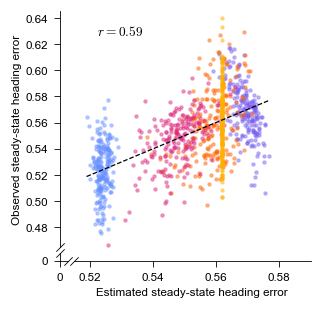

tt5 = 39.2469 + -140.1517 * SectionVariance + 69.1778 * Close


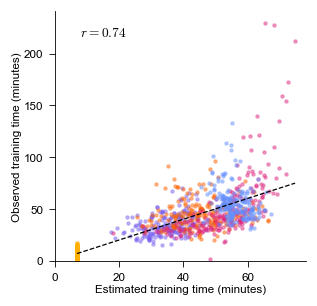

In [15]:
cols_to_norm = ["SectionVariance", "Close"]

df_clean = df_boot.dropna().copy()
df_std = df_clean.copy()

for col in cols_to_norm:
    if df_std[col].std() > 0:
        df_std[col] = (df_std[col] - df_std[col].mean()) / df_std[col].std()

for target_var in ["A", "tt5"]:
    # Linear mixed model with random intercept per group
    formula = f"{target_var} ~ " + " + ".join(cols_to_norm)

    model_all = smf.mixedlm(formula, data=df_std, groups=df_std["Group"]).fit()

    predictions = model_all.fittedvalues
    actual = df_std[target_var]

    print(f"{target_var} = {model_all.params['Intercept']:.4f} + " + " + ".join([f"{model_all.params[col]:.4f} * {col}" for col in cols_to_norm]))

    if target_var == "A":
        fig, axs = create_split_plot_xy()
        ax = axs[1]
        ax.set_xlabel("Estimated steady-state heading error", labelpad=24)
        ax.set_ylabel("Observed steady-state heading error", labelpad=31)
        ax.set_xticks(np.arange(0.5, 0.591, 0.02))
        ax.set_yticks(np.arange(0.46, 0.65, 0.02))
        ax.set_xlim(0.515, 0.59)
        ax.set_ylim(0.465, 0.645)
    elif target_var == "tt5":
        fig, ax = plt.subplots(figsize=(2.7, 2.7), dpi=120)
        ax.set_xlabel("Estimated training time (minutes)", labelpad=1)
        ax.set_ylabel("Observed training time (minutes)", labelpad=1)

    for group in df_std["Group"].unique():
        idx = df_std["Group"] == group
        ax.scatter(predictions[idx], actual[idx], alpha=0.4, color=group_colors.get(group, 'purple'), label=group, s=3)

    m, b = np.polyfit(predictions, actual, 1)
    x_range = np.linspace(predictions.min(), predictions.max(), 100)
    ax.plot(x_range, m*x_range + b, color="black", linestyle="--", label="Fit")
    corr = np.corrcoef(predictions, actual)[0,1]
    ax.text(0.1, 0.9, rf"$r = {corr:.2f}$", transform=ax.transAxes, fontsize=8)

    if target_var == "tt5":
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

    save_path = f"./plot/corr_{target_var}.png"
    fig.patch.set_visible(False)
    fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
    fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
    fig.patch.set_visible(True)
    plt.show()

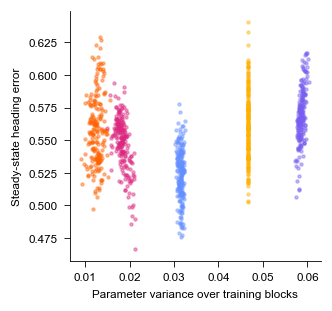

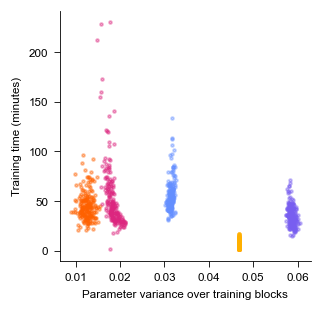

In [17]:
metric = "SectionVariance"

ylabels = {
    "A": "Steady-state heading error",
    "tt5": "Training time (minutes)",
}
xlabels = {
    "SectionVariance": "Parameter variance over training blocks",
    "Close": "Num. parameters close to an eval parameter"
}

for target_var in ["A", "tt5"]:
    fig = plt.figure(figsize=(2.7, 2.7), dpi=120)
    for group in df_clean["Group"].unique():
        idx = df_clean["Group"] == group
        plt.scatter(df_clean[metric][idx], df_clean[target_var][idx], alpha=0.4, color=group_colors.get(group, 'purple'), label=group, s=3)
    plt.xlabel(xlabels[metric])
    plt.ylabel(ylabels[target_var])

    save_path = f"./plot/corr_{metric}_{target_var}.png"
    fig.patch.set_visible(False)
    fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
    fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
    fig.patch.set_visible(True)
    plt.show()

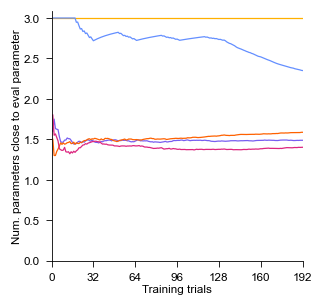

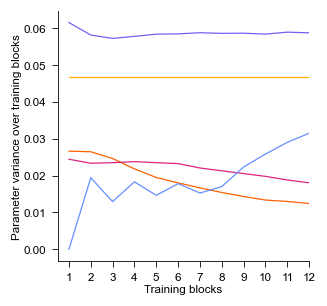

In [11]:
groups = [params_random, params_perf, params_pref, params_const, params_var]
labels = ["Random", "Error", "Pref", "Const", "Var"]

fig, ax = plt.subplots(figsize=(2.7, 2.7), dpi=120)
for i, group in enumerate(groups):
    values = []
    for j in range(1,193):
        slice = group[:,:j,:].copy()
        values.append(individual_close(slice))
    plt.plot(np.arange(192)+1, values, label=labels[i], color=group_colors[labels[i]])
plt.xlabel("Training trials", labelpad=1)
plt.ylabel("Num. parameters close to eval parameter", labelpad=1)
plt.xlim(left=0, right=192)
plt.ylim(bottom=0)
plt.xticks([0, 32, 64, 96, 128, 160, 192])
save_path = f"./plot/metric_specificity.png"
fig.patch.set_visible(False)
fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
fig.patch.set_visible(True)
plt.show()

fig, ax = plt.subplots(figsize=(2.7, 2.7), dpi=120)
for i, group in enumerate(groups):
    values = []
    if labels[i] == "Var":
        indices = [18,33,51,66,84,99,117,132,148,164,180,196]
    else:
        indices = [16,32,48,64,80,96,112,128,144,160,176,192]

    for idx in indices:
        slice = group[:,:idx,:].copy()
        values.append(section_variance(slice))
    plt.plot(np.arange(12) + 1, values, label=labels[i], color=group_colors[labels[i]])
plt.xticks(np.arange(12) + 1)
plt.xlim(0.5,12)
plt.xlabel("Training blocks", labelpad=1)
plt.ylabel("Parameter variance over training blocks", labelpad=1)
save_path = f"./plot/metric_variance.png"
fig.patch.set_visible(False)
fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
fig.patch.set_visible(True)
plt.show()